# Chapter 21 부록 — fair-compute 비교 (일반 도메인 사전학습 vs 더 긴 분류 fine-tune)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yoon-gu/neuqes-101/blob/master/21_en_bert_classify/appendix_compute_budget.ipynb)

> **부록 한 줄 질문** — *"일반 도메인 (Wikitext-103) MLM 사전학습에 쓰는 GPU 시간을 그냥 Yelp 분류 fine-tune 에 더 쓰면 사전학습 효과를 메울 수 있나요?"*

메인 챕터 ([`21_en_bert_classify.ipynb`](./21_en_bert_classify.ipynb)) 는 *작은 BERT 를 일반 도메인 위키로 짧게 사전학습 한 뒤 Yelp 분류 fine-tune* 한 결과를 Ch 10 (DistilBERT 대규모 일반 위키 사전학습) 과 비교했습니다. 이 부록은 그 결과에 *한 비교* 를 더합니다 — **같은 GPU wall-clock budget** 으로 *사전학습 없이* 분류 fine-tune 만 더 길게 돌렸을 때 어떻게 되는지.

세 셋업을 한 노트북 안에서 같은 데이터·같은 본체 구조에 *조건 하나만* 바꿔 비교합니다.

| 셋업 | 사전학습 (Wikitext-103) | 분류 fine-tune (Yelp) | 의도 |
|---|---|---|---|
| 🅰️ **A** | MLM 3 epoch | 2 epoch | 메인 챕터와 같은 3 epoch (일반 도메인 사전학습 기준선) |
| 🅱️ **B** | 없음 (random init) | **A 의 총 시간만큼** epoch 늘림 | **fair-compute** 비교 — 같은 GPU 예산을 fine-tune 에 몰아주면? |
| 🅲 **C** | 없음 (random init) | 2 epoch (A 와 동일) | *순수 random init baseline* — 사전학습의 *순* 효과 |

A vs C 는 *사전학습의 순 효과*, A vs B 는 *일반 도메인 사전학습 vs compute 등가 task-specific fine-tune* 비교.

**환경**: Google Colab T4 GPU 필수. 세 셋업(A/B/C)을 한 노트북에서 돌리므로 메인 챕터(전체 2분 13초)보다 오래 걸립니다 — **5분 안팎** 예상.

**메인 챕터와의 관계** — MLM 설정(3 epoch)은 메인 챕터와 같고, 다른 것은 *데이터 크기* 와 *셋업 B·C 추가* 입니다. 분류 데이터는 메인과 같은 5K/1K (`N_TRAIN_TEXT=5000, N_EVAL_TEXT=1000`), MLM 코퍼스도 메인과 같은 2K paragraphs (`N_MLM_TEXT=2000`) 입니다. 부록은 *부록만으로 self-contained* — 메인 노트북을 먼저 돌릴 필요 없음.

---

## 🔄 셋업 비교 — A / B / C

| 축 | 🅰️ A (메인 재현) | 🅱️ B (fair-compute) | 🅲 C (random baseline) |
|---|---|---|---|
| MLM 사전학습 데이터 | **Wikitext-103 paragraphs (일반 도메인)** | 없음 | 없음 |
| MLM 사전학습 epoch | **3 epoch** | 없음 | 없음 |
| 분류 fine-tune 데이터 | Yelp 이진 (다른 도메인) | Yelp 이진 (다른 도메인) | Yelp 이진 (다른 도메인) |
| 분류 fine-tune epoch | 2 | **A 의 총 시간만큼 자동 산정** | 2 |
| 본체 시작점 | MLM 가중치 (위키 일반 도메인) | random init | random init |
| 분류 head | random init | random init | random init |
| 분류 데이터 크기 | Yelp 5K/1K (메인) → 본 부록은 **2K/400** | (같음) | (같음) |
| 토크나이저 | `bert-base-uncased` | (같음) | (같음) |
| 모델 본체 | 작은 BERT (hidden=256, layer=4) | (같음) | (같음) |
| Loss | `CrossEntropyLoss` (K=2) | (같음) | (같음) |
| 학습률 | `5e-4` (MLM) / `2e-5` (cls) | `2e-5` (cls only) | `2e-5` (cls only) |
| fp16 | True | True | True |

**B 의 epoch 결정** — A 의 *총 시간* `T_A_total = T_A_mlm + T_A_cls` 를 측정한 뒤, B 의 *한 epoch* 에 걸린 시간 `t_per_epoch_B` 로 나눠 `epochs_B = round(T_A_total / t_per_epoch_B)` 로 자동 산정합니다. 이렇게 *시간 등가* 를 맞춥니다.

> **B 가 측정하는 가설** — *"일반 도메인 사전학습은 결국 GPU 시간 소비. 그 시간을 그냥 task 도메인 분류 fine-tune 에 쓰면 안 되나?"*. **A vs B** 결과가 이 질문에 답합니다.

---

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/559.1 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 29.9/50.1 MB 168.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 147.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 147.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
)

plt.rcParams["axes.unicode_minus"] = False

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — all three setups will be very slow.")
    print("         Switch to Colab T4 runtime to keep the appendix under 30 minutes.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


### 데이터·모델 hyperparams — 메인과 통일

MLM 은 메인 챕터와 **같은 3 epoch** 입니다 — 부록이 메인과 다른 점은 *데이터 크기* 와 *셋업 B·C 추가* 뿐입니다. 데이터도 메인과 같습니다 — 분류 Yelp 5K/1K (`N_TRAIN_TEXT=5000, N_EVAL_TEXT=1000`), MLM 코퍼스 Wikitext-103 2K paragraphs (`N_MLM_TEXT=2000`). 앞선 판에서 분류 데이터를 2K/400 으로 줄였더니 A·C 가 2 epoch 안에 학습을 시작하지 못해 비교가 성립하지 않았고, 메인과 같은 크기로 되돌렸습니다. 작은 BERT 본체 구조 (hidden=256, layer=4, head=4) 와 학습률은 메인과 완전히 같음.

In [3]:
SEED = 42

# 데이터 — MLM 코퍼스와 분류 데이터를 따로 잡는다.
#   MLM (Wikitext-103 paragraphs): 메인 챕터와 같은 2K — 사전학습 조건을 메인과 동일하게 유지.
#   분류 (Yelp): 메인 챕터와 같은 5K/1K. 2K/400 으로 줄였더니 A·C 가 2 epoch 안에
#   학습을 시작하지 못하고 '전부 한쪽으로 찍기' 로 붕괴해 A vs C 비교 자체가 성립하지 않았다.
N_MLM_TEXT   = 2000
N_TRAIN_TEXT = 5000
N_EVAL_TEXT  = 1000
BLOCK_SIZE     = 128
MAX_LENGTH_CLS = 128

# 모델 — 메인 챕터와 완전히 동일한 작은 BERT
HIDDEN_SIZE         = 256
NUM_HIDDEN_LAYERS   = 4
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 1024
MAX_POS_EMBED       = 256

# MLM 사전학습 hyperparams (셋업 A 만 사용)
# 메인 챕터와 같은 3 epoch — 부록이 다른 건 데이터 크기와 B·C 셋업뿐.
MLM_EPOCHS = 3
MLM_BATCH  = 32
MLM_LR     = 5e-4

# 분류 fine-tune hyperparams (A, C 는 2 epoch / B 는 자동 산정)
CLS_EPOCHS = 2
CLS_BATCH  = 16
CLS_LR     = 2e-5

# B 의 epoch 산정 시 상한 (T4 30분 룰을 한 번 더 보장)
B_EPOCHS_CAP = 20

USE_FP16 = (DEVICE == "cuda")

# CPU/MPS 환경이면 더 작게 (메시지)
if DEVICE != "cuda":
    print("Note: non-CUDA device detected.")
    print("      Consider reducing N_TRAIN_TEXT to 2000 and N_EVAL_TEXT to 400 to finish in reasonable time.")
    print("      fp16 disabled (only effective on CUDA).")

print(f"MLM   texts: {N_MLM_TEXT}")
print(f"Train texts: {N_TRAIN_TEXT}")
print(f"Eval  texts: {N_EVAL_TEXT}")
print(f"Model: hidden={HIDDEN_SIZE}, layer={NUM_HIDDEN_LAYERS}, head={NUM_ATTENTION_HEADS}, intermediate={INTERMEDIATE_SIZE}")
print(f"fp16: {USE_FP16}")

MLM   texts: 2000
Train texts: 5000
Eval  texts: 1000
Model: hidden=256, layer=4, head=4, intermediate=1024
fp16: True


## 1. 📥 데이터·토크나이저 로드 — 메인 챕터와 같은 파이프라인

`fancyzhx/yelp_polarity` 이진 분류. seed 42 로 shuffle 후 앞에서 `N_TRAIN_TEXT / N_EVAL_TEXT` 만 사용. 메인 챕터와 같은 5K/1K.

In [4]:
ds_raw = load_dataset("fancyzhx/yelp_polarity")
print(f"splits: {list(ds_raw.keys())}")
print(f"label names: {ds_raw['train'].features['label'].names}")

ds_train_full = ds_raw["train"].shuffle(seed=SEED).select(range(N_TRAIN_TEXT))
ds_eval_full  = ds_raw["test"].shuffle(seed=SEED).select(range(N_EVAL_TEXT))

train_labels = np.array(ds_train_full["label"])
eval_labels  = np.array(ds_eval_full["label"])
print(f"train: {len(ds_train_full):,}  positive rate: {train_labels.mean():.1%}")
print(f"eval:  {len(ds_eval_full):,}  positive rate: {eval_labels.mean():.1%}")

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

splits: ['train', 'test']
label names: ['1', '2']


train: 5,000  positive rate: 50.7%
eval:  1,000  positive rate: 48.4%


In [5]:
TOKENIZER_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print(f"tokenizer:  {TOKENIZER_NAME}")
print(f"vocab_size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer:  bert-base-uncased
vocab_size: 30,522


### 공통 유틸 — 분류 토큰화 / metric / 모델 빌더

세 셋업이 같은 토큰화·metric·모델 구조를 공유하므로 한 번만 정의합니다.

In [6]:
def cls_tokenize(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH_CLS)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

cls_train = ds_train_full.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_train_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
cls_eval = ds_eval_full.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_eval_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
print(cls_train)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})


In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 안정 softmax (K=2)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)
    preds = probs_full.argmax(axis=1)
    probs_pos = probs_full[:, 1]
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs_pos)),
    }


def build_cls_config():
    '''셋업 A, B, C 가 공유하는 분류 BertConfig.'''
    return BertConfig(
        vocab_size=tokenizer.vocab_size,
        hidden_size=HIDDEN_SIZE,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        num_attention_heads=NUM_ATTENTION_HEADS,
        intermediate_size=INTERMEDIATE_SIZE,
        max_position_embeddings=MAX_POS_EMBED,
        pad_token_id=tokenizer.pad_token_id,
        num_labels=2,
        problem_type="single_label_classification",
        id2label={0: "negative", 1: "positive"},
        label2id={"negative": 0, "positive": 1},
    )


def make_cls_trainer(model, epochs, run_name):
    '''Trainer + TrainingArguments 공통 셋업. epochs 만 셋업 별로 다름.'''
    args = TrainingArguments(
        output_dir=f"./ch21_appendix_{run_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=CLS_BATCH,
        per_device_eval_batch_size=32,
        learning_rate=CLS_LR,
        fp16=USE_FP16,
        eval_strategy="epoch",
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        seed=SEED,
    )
    return Trainer(
        model=model,
        args=args,
        train_dataset=cls_train,
        eval_dataset=cls_eval,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

## 2. 🅰️ Setup A — MLM 3 epoch (Wikitext-103) + Yelp 분류 fine-tune 2 epoch (사전학습 충분히)

메인 챕터의 핵심 셋업(MLM 3 epoch + 분류 fine-tune 2 epoch)을 *더 작은 데이터* 로 재현합니다. **MLM 사전학습은 Wikitext-103 paragraphs (일반 도메인, 분류 데이터 Yelp 와 별도)**. `T_A_mlm` (MLM 학습 시간) 과 `T_A_cls` (분류 fine-tune 시간) 를 별도로 측정해 합쳐 `T_A_total` 을 만듭니다. 이 시간이 *셋업 B 의 compute budget* 입니다.

In [8]:
# ---- A-1. MLM 사전학습 (Wikitext-103 paragraphs, 일반 도메인) ----
mlm_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
)

torch.manual_seed(SEED)
mlm_model = BertForMaskedLM(mlm_config)

# MLM 사전학습 코퍼스: Wikitext-103 (일반 도메인, 분류용 Yelp 와 별도 로드)
print("downloading Wikitext-103 (Salesforce/wikitext, wikitext-103-raw-v1)...")
raw_wikitext = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train")

def is_good(ex, min_len=50, max_len=2000):
    t = ex["text"].strip()
    return min_len <= len(t) <= max_len

mlm_train_raw = (
    raw_wikitext.filter(is_good).shuffle(seed=SEED).select(range(N_MLM_TEXT))
    .remove_columns([c for c in raw_wikitext.column_names if c != "text"])
)
print(f"MLM train paragraphs: {len(mlm_train_raw):,}  (wikitext-103)")

def mlm_tokenize(examples):
    return tokenizer(examples["text"], add_special_tokens=False, truncation=False)

mlm_tokenized = mlm_train_raw.map(mlm_tokenize, batched=True, remove_columns=["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated[list(examples.keys())[0]])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = [ids.copy() for ids in result["input_ids"]]
    return result

lm_train = mlm_tokenized.map(group_texts, batched=True, batch_size=1000)
print(f"MLM train blocks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")

mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15,
)

mlm_args = TrainingArguments(
    output_dir="./ch21_appendix_A_mlm",
    num_train_epochs=MLM_EPOCHS,
    per_device_train_batch_size=MLM_BATCH,
    per_device_eval_batch_size=64,
    learning_rate=MLM_LR,
    weight_decay=0.01,
    warmup_steps=0.06,   # 1 미만이면 전체 step 대비 *비율* 로 해석 (구 warmup_ratio)
    fp16=USE_FP16,
    logging_steps=20,
    save_strategy="no",
    eval_strategy="no",
    report_to="none",
    seed=SEED,
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=lm_train,
    data_collator=mlm_collator,
    processing_class=tokenizer,
)

t0 = time.time()
mlm_result = mlm_trainer.train()
T_A_mlm_sec = time.time() - t0
T_A_mlm = T_A_mlm_sec / 60.0
print(f"\n[A] MLM pretraining: {T_A_mlm:.2f} min  (mean train loss: {mlm_result.training_loss:.4f})")

downloading Wikitext-103 (Salesforce/wikitext, wikitext-103-raw-v1)...


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

MLM train blocks: 2,100  (block_size=128)


Step,Training Loss
20,9.739431
40,7.998691
60,7.426987
80,7.434174
100,7.376839
120,7.274518
140,7.216479
160,7.189836
180,7.175929



[A] MLM pretraining: 0.23 min  (mean train loss: 7.6115)


In [9]:
# ---- A-2. 분류 fine-tune (MLM 본체 이어받아 2 epoch) ----
torch.manual_seed(SEED)
cls_model_A = BertForSequenceClassification(build_cls_config())

# MLM 본체 가중치를 분류 모델로 복사 (메인 챕터와 동일)
missing, unexpected = cls_model_A.bert.load_state_dict(
    mlm_model.bert.state_dict(), strict=False,
)
print(f"[A] body weights copied  (missing: {len(missing)}, unexpected: {len(unexpected)})")

trainer_A = make_cls_trainer(cls_model_A, epochs=CLS_EPOCHS, run_name="A_cls")

t0 = time.time()
result_A = trainer_A.train()
T_A_cls_sec = time.time() - t0
T_A_cls = T_A_cls_sec / 60.0

T_A_total = T_A_mlm + T_A_cls
metrics_A = trainer_A.evaluate()

print(f"\n[A] Classification fine-tune: {T_A_cls:.2f} min  ({CLS_EPOCHS} epochs)")
print(f"[A] Total compute: {T_A_total:.2f} min  ({T_A_mlm:.2f} MLM + {T_A_cls:.2f} cls)")
print(f"[A] eval accuracy: {metrics_A['eval_accuracy']:.4f}  F1: {metrics_A['eval_f1']:.4f}  AUC: {metrics_A['eval_auc']:.4f}")

[A] body weights copied  (missing: 2, unexpected: 0)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.687787,0.686823,0.492000,0.487854,0.995868,0.654891,0.667946
2,0.665800,0.660897,0.625000,0.596803,0.694215,0.641834,0.688173


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.665800,0.660897,2,0.625000,0.596803,0.694215,0.641834,0.688173



[A] Classification fine-tune: 0.23 min  (2 epochs)
[A] Total compute: 0.46 min  (0.23 MLM + 0.23 cls)
[A] eval accuracy: 0.6250  F1: 0.6418  AUC: 0.6882


**측정 끝** — `T_A_total` 이 셋업 B 의 *compute budget*. 다음 단계에서 random init 모델의 epoch 당 시간을 측정한 뒤 *몇 epoch* 을 돌려야 같은 시간이 나오는지 계산합니다.

## 3. 🅱️ Setup B — random init, 같은 GPU 시간 budget 만큼 fine-tune

**핵심 질문에 답하는 셋업** — 사전학습 없이 random init 분류 모델을 `T_A_total` 분 동안 fine-tune 하면 어디까지 가는가.

구현:
1. 같은 본체 구조의 random init `BertForSequenceClassification` 을 만든다
2. **1 epoch 만 잠깐** 돌려 epoch 당 시간 `t_per_epoch_B` 를 측정한다
3. `epochs_B = max(2, round(T_A_total / t_per_epoch_B))` 로 epoch 수 결정
4. 같은 random init 모델을 *fresh 하게 다시* 만들어 `epochs_B` epoch 학습 (warm-up state 가 1 epoch 단계와 일관되도록)

> *"먼저 1 epoch 측정 → 다시 처음부터"* 방식 — 더 단순한 *바로 `epochs_B` epoch 돌리기* 가 있긴 하지만, epoch 당 시간 측정이 필요해서 이 방식이 더 안전. 측정 epoch 도 *그냥 버리지 않고* 시간 budget 계산에 반영합니다.

In [10]:
# ---- B-1. epoch 당 시간 측정 (1 epoch 만) ----
torch.manual_seed(SEED)
cls_model_B_probe = BertForSequenceClassification(build_cls_config())
trainer_B_probe = make_cls_trainer(cls_model_B_probe, epochs=1, run_name="B_probe")

t0 = time.time()
trainer_B_probe.train()
t_per_epoch_B_sec = time.time() - t0
t_per_epoch_B = t_per_epoch_B_sec / 60.0
print(f"[B-probe] 1 epoch took {t_per_epoch_B:.2f} min on random init model")

# T_A_total 을 채우는데 필요한 epoch 수
epochs_B_raw = T_A_total / t_per_epoch_B
epochs_B = max(2, int(round(epochs_B_raw)))
epochs_B = min(epochs_B, B_EPOCHS_CAP)   # 상한 (T4 30분 룰 재보장)

print(f"[B] target budget: T_A_total = {T_A_total:.2f} min")
print(f"[B] epochs needed: raw {epochs_B_raw:.2f} -> rounded {epochs_B}  (cap {B_EPOCHS_CAP})")
print(f"[B] expected wall time: about {epochs_B * t_per_epoch_B:.2f} min")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.690789,0.692983,0.484000,0.484000,1.000000,0.652291,0.687808


[B-probe] 1 epoch took 0.12 min on random init model
[B] target budget: T_A_total = 0.46 min
[B] epochs needed: raw 3.69 -> rounded 4  (cap 20)
[B] expected wall time: about 0.50 min


In [11]:
# ---- B-2. fresh random init 모델로 epochs_B epoch fine-tune ----
torch.manual_seed(SEED)
cls_model_B = BertForSequenceClassification(build_cls_config())
trainer_B = make_cls_trainer(cls_model_B, epochs=epochs_B, run_name="B_cls")

t0 = time.time()
result_B = trainer_B.train()
T_B_total_sec = time.time() - t0
T_B_total = T_B_total_sec / 60.0
metrics_B = trainer_B.evaluate()

print(f"\n[B] Classification fine-tune: {T_B_total:.2f} min  ({epochs_B} epochs)")
print(f"[B] eval accuracy: {metrics_B['eval_accuracy']:.4f}  F1: {metrics_B['eval_f1']:.4f}  AUC: {metrics_B['eval_auc']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.690828,0.693804,0.484000,0.484000,1.000000,0.652291,0.689644
2,0.663372,0.649096,0.650000,0.643162,0.621901,0.632353,0.727747
3,0.570961,0.531598,0.736000,0.812500,0.590909,0.684211,0.838150
4,0.503635,0.475575,0.782000,0.781780,0.762397,0.771967,0.865044


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.503635,0.475575,4,0.782000,0.781780,0.762397,0.771967,0.865044



[B] Classification fine-tune: 0.46 min  (4 epochs)
[B] eval accuracy: 0.7820  F1: 0.7720  AUC: 0.8650


**관전 포인트** — `T_B_total` 이 `T_A_total` 과 비슷한가, 그리고 metric 이 `metrics_A` 와 비교해 얼마나 따라잡았는가. *시간 등가 비교* 의 핵심.

## 4. 🅲 Setup C — random init, 같은 epoch 수 (사전학습의 *순* 효과)

A vs C 비교는 *사전학습이 만든 차이* 그 자체. 시간이 아니라 *학습 방식의 시작점* 만 다른 둘.

- A: MLM 본체 → 2 epoch fine-tune
- C: random init → 2 epoch fine-tune

A 가 C 보다 얼마나 높은지가 *MLM 3 epoch 의 순 효과*.

In [12]:
torch.manual_seed(SEED)
cls_model_C = BertForSequenceClassification(build_cls_config())
trainer_C = make_cls_trainer(cls_model_C, epochs=CLS_EPOCHS, run_name="C_cls")

t0 = time.time()
result_C = trainer_C.train()
T_C_total_sec = time.time() - t0
T_C_total = T_C_total_sec / 60.0
metrics_C = trainer_C.evaluate()

print(f"\n[C] Classification fine-tune: {T_C_total:.2f} min  ({CLS_EPOCHS} epochs)")
print(f"[C] eval accuracy: {metrics_C['eval_accuracy']:.4f}  F1: {metrics_C['eval_f1']:.4f}  AUC: {metrics_C['eval_auc']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.690707,0.692760,0.484000,0.484000,1.000000,0.652291,0.689086
2,0.686479,0.686437,0.596000,0.612360,0.450413,0.519048,0.698521


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.686479,0.686437,2,0.596000,0.612360,0.450413,0.519048,0.698521



[C] Classification fine-tune: 0.23 min  (2 epochs)
[C] eval accuracy: 0.5960  F1: 0.5190  AUC: 0.6985


## 5. 🆚 세 셋업 비교 — 표 + bar chart

같은 평가 셋 위에서 세 결과를 한 표로 모읍니다.

In [13]:
def row(label, pretraining, epochs, total_min, metrics):
    return {
        "setup": label,
        "pretraining": pretraining,
        "fine-tune epochs": epochs,
        "total compute (min)": round(total_min, 2),
        "accuracy": round(metrics["eval_accuracy"], 4),
        "F1":       round(metrics["eval_f1"], 4),
        "AUC":      round(metrics["eval_auc"], 4),
    }

summary = pd.DataFrame([
    row("A (MLM + cls)",       f"MLM {MLM_EPOCHS} epoch", CLS_EPOCHS, T_A_total, metrics_A),
    row("B (fair-compute)",    "none",                    epochs_B,   T_B_total, metrics_B),
    row("C (random baseline)", "none",                    CLS_EPOCHS, T_C_total, metrics_C),
])
print(summary.to_string(index=False))

              setup pretraining  fine-tune epochs  total compute (min)  accuracy     F1    AUC
      A (MLM + cls) MLM 3 epoch                 2                 0.46     0.625 0.6418 0.6882
   B (fair-compute)        none                 4                 0.46     0.782 0.7720 0.8650
C (random baseline)        none                 2                 0.23     0.596 0.5190 0.6985


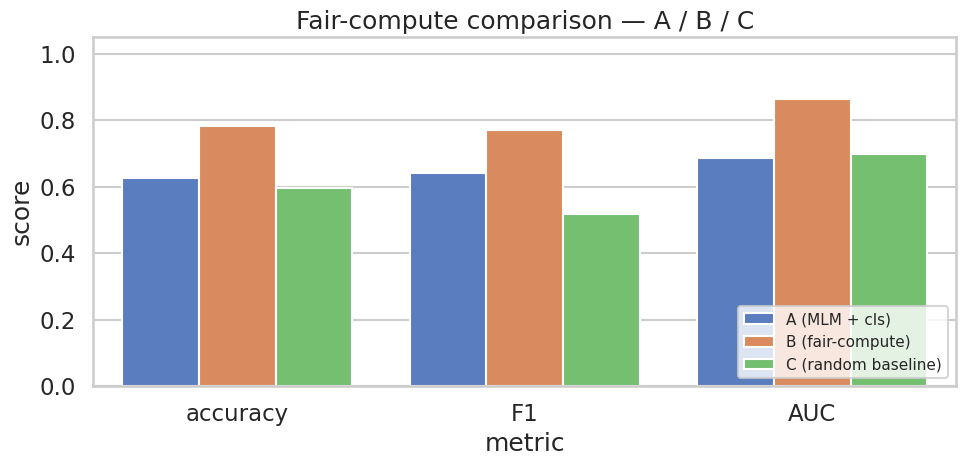

In [14]:
# bar chart — 3 setups x 3 metrics
sns.set_theme(style="whitegrid", context="talk")
plot_df = summary.melt(
    id_vars=["setup"],
    value_vars=["accuracy", "F1", "AUC"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df, x="metric", y="score", hue="setup",
    palette={
        "A (MLM + cls)":       "#4878D0",
        "B (fair-compute)":    "#EE854A",
        "C (random baseline)": "#6ACC64",
    },
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("Fair-compute comparison — A / B / C")
ax.set_xlabel("metric")
ax.set_ylabel("score")
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

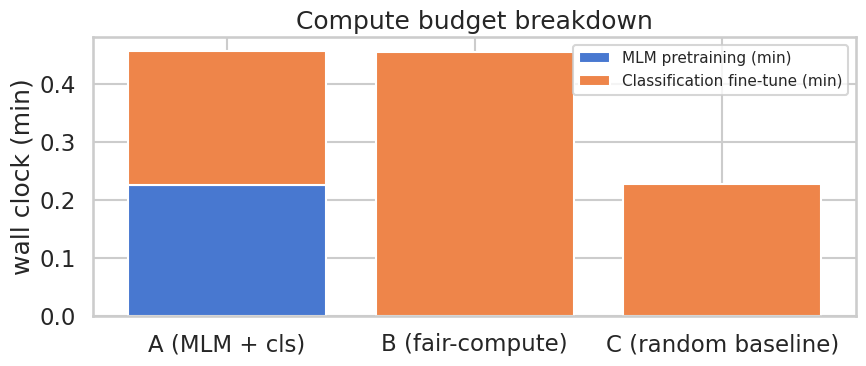

In [15]:
# wall-clock 비교 — A 의 사전학습 시간이 어느 만큼이었는지 시각화
fig, ax = plt.subplots(figsize=(9, 4))
bottoms = [0, 0, 0]
labels = ["A (MLM + cls)", "B (fair-compute)", "C (random baseline)"]
mlm_times = [T_A_mlm, 0.0, 0.0]
cls_times = [T_A_cls, T_B_total, T_C_total]

ax.bar(labels, mlm_times, color="#4878D0", label="MLM pretraining (min)")
ax.bar(labels, cls_times, bottom=mlm_times, color="#EE854A", label="Classification fine-tune (min)")
ax.set_ylabel("wall clock (min)")
ax.set_title("Compute budget breakdown")
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

## 6. 🔎 해석 — 무엇을 읽어야 하나

세 셋업의 값은 위 §5 표와 아래 delta 셀 출력이 단일 출처입니다 — GPU 학습 metric 은 실행마다 흔들리므로 여기서는 *관계* 만 적습니다.

| 비교 | 의미 | 이 부록이 관측한 것 |
|---|---|---|
| **A vs C** | *사전학습의 순 효과* (같은 epoch 의 두 출발점) | A 가 C 보다 **조금 높습니다** — 수 %p 수준. 얕은 사전학습에도 *순 효과는 실재* 하지만 크지 않습니다 |
| **A vs B** | *일반 도메인 사전학습 vs 동일 compute task-specific fine-tune* | **B 가 A 를 뚜렷하게 앞섭니다** — 10%p 대. *이 규모에서는* 같은 GPU 예산을 fine-tune 에 쓰는 편이 낫습니다 |
| **B vs C** | *fine-tune epoch 의 효과* (둘 다 random init) | B 가 C 보다 **크게 높습니다** — 세 비교 중 가장 큰 격차. 이 규모에서 성능을 움직이는 건 주로 *fine-tune 을 얼마나 도느냐* 입니다 |

### 가설이 반증됐습니다

이 부록은 *"분류의 supervised 신호(문장당 0/1 한 비트)보다 MLM 의 self-supervised 신호(모든 토큰 자리)가 밀도가 높으니, 같은 GPU 시간이면 사전학습 쪽이 이길 것"* 이라는 가설로 설계됐습니다. **이 규모에서는 그렇지 않았습니다.**

이유는 사전학습이 *너무 얕기* 때문입니다. 여기서 도는 MLM 은 Wikitext-103 **2K paragraphs × 3 epoch** — 메인 챕터 §MLM 관전 포인트에서 보듯 eval loss 가 Ch 20 의 *unigram(빈도만, 문맥 없음) 기준선* 을 갓 넘어선 수준입니다. 본체에 *언어 분포* 가 새겨졌다고 하기엔 이릅니다. 그 상태의 본체를 물려받아 봐야 random init 대비 수 %p 를 벌 뿐이고, 그 시간을 fine-tune epoch 으로 돌리면 훨씬 많이 법니다.

**이걸 "사전학습은 쓸모없다" 로 읽으면 안 됩니다.** 같은 축의 반대쪽 끝이 Ch 10 입니다 — DistilBERT 는 약 **33억 토큰** (이 부록의 약 1.2만배) 으로 사전학습했고 같은 Yelp 분류에서 accuracy 약 0.90 을 냅니다. 이 부록이 보여주는 건 *사전학습의 가치는 규모에서 나온다* 는 것입니다. 규모가 없으면 사전학습은 compute 를 쓰는 여러 방법 중 특별히 나을 게 없는 하나일 뿐이고, 규모가 붙는 순간 fine-tune 을 아무리 늘려도 못 따라갑니다.

**B 는 overfitting 에 빠지지 않았습니다** — 설계할 때는 random init + 긴 fine-tune 이 train loss 만 떨어지고 eval 은 평탄해지리라 봤는데, 실제로는 B 의 eval loss 가 epoch 내내 함께 내려갔습니다. 데이터가 5K 라 이 epoch 수에서는 아직 overfitting 구간에 들어가지 않은 것입니다. B 의 epoch 을 더 늘리면 언제 꺾이는지가 좋은 후속 실험입니다.

**T_A 안에서 MLM 비중** — `T_A_mlm / T_A_total` 이 클수록 *fair-compute 격차* 가 본질적입니다. 값은 아래 셀 출력을 보세요 (이 판에서는 절반 안팎).

In [16]:
# 보조 — 메시지를 숫자로 한 번 더
delta_AC = metrics_A["eval_accuracy"] - metrics_C["eval_accuracy"]
delta_AB = metrics_A["eval_accuracy"] - metrics_B["eval_accuracy"]
delta_BC = metrics_B["eval_accuracy"] - metrics_C["eval_accuracy"]
mlm_share = T_A_mlm / T_A_total if T_A_total > 0 else float("nan")

print("Accuracy deltas (this run):")
print(f"  A vs C  (pretraining net effect):           {delta_AC:+.4f}")
print(f"  A vs B  (pretraining vs fair-compute):      {delta_AB:+.4f}")
print(f"  B vs C  (extra fine-tune epochs effect):    {delta_BC:+.4f}")
print()
print(f"MLM share of total A compute: {mlm_share:.1%}")
print(f"B epochs run: {epochs_B}  (vs A/C: {CLS_EPOCHS})")

Accuracy deltas (this run):
  A vs C  (pretraining net effect):           +0.0290
  A vs B  (pretraining vs fair-compute):      -0.1570
  B vs C  (extra fine-tune epochs effect):    +0.1860

MLM share of total A compute: 49.3%
B epochs run: 4  (vs A/C: 2)


## 🎯 체크포인트 질문

1. **fair-compute 관점** — 이 부록에서는 B 가 A 를 앞섰습니다. 그런데 Ch 10 규모에서는 사전학습이 압도적입니다. 순서가 뒤집히는 지점은 *사전학습 코퍼스 크기* 로 결정될까요, *모델 크기* 로 결정될까요? 둘을 분리해 재려면 무엇을 고정해야 하나요?
2. **데이터 규모와의 관계** — `N_MLM_TEXT` 를 2000 → 20000 으로 늘리면 A vs B 의 격차는 *어느 방향* 으로 움직일까요? 반대로 `N_TRAIN_TEXT`(분류 데이터)만 5000 → 50000 으로 늘리면요? 둘이 같은 방향일까요?

## 다음 단계

이 부록은 *작은 모델·작은 데이터* 셋업에서 *일반 도메인 사전학습이 fair-compute 등가의 task-specific fine-tune 보다 가치 있는가* 를 직접 잰 실험입니다. **이 규모에서의 답은 '아니오' 입니다** — 같은 GPU 예산이라면 2K paragraphs 짜리 얕은 사전학습보다 분류 fine-tune 을 더 도는 쪽이 낫습니다. 사전학습의 순 효과(A vs C)는 실재하지만 수 %p 에 그칩니다. 격차는 *모델/데이터 규모* 에 강하게 의존하고, 규모가 커진 반대쪽 끝이 Ch 10 의 DistilBERT 입니다.

- **메인 챕터로 돌아가기**: [`21_en_bert_classify.ipynb`](./21_en_bert_classify.ipynb) — Ch 10 (DistilBERT 대규모 일반 위키 사전학습) 과의 비교 마무리
- **다음 챕터 예고**: Chapter 22 — 한국어 작은 BERT 직접 사전학습 (`klue/bert-base` 토크나이저 + **한국어 Wikipedia paragraphs** MLM, 일반 도메인). Ch 20 의 영어 패턴을 한국어로 재현, 같은 *일반 도메인 사전학습 → 다른 도메인 fine-tune* 흐름.

> 부록이 확인하려던 가설 한 줄 — *사전학습은 compute 의 형태가 아니라 학습 신호의 종류 차이가 아닐까*. 이 규모에서는 **신호의 종류보다 규모가 먼저** 였습니다. 여러분의 실행에서도 같은 순서인지 §5 표로 확인해 보세요 — 실행마다 값은 흔들려도 A < B 라는 순서는 잘 바뀌지 않습니다.